In [29]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df.shape

(18315, 6)

In [31]:
df = pd.read_csv('/content/tassi-di-suicidio-globali-per-paese-2000-2021.csv')
df.head()

,iso_code,country,year,sex,age_group,suicide_rate
0,AFG,Afghanistan,2000,male,ALL,5.793457
1,AFG,Afghanistan,2000,both,ALL,4.356148
2,AFG,Afghanistan,2000,female,ALL,2.910393
3,AFG,Afghanistan,2001,male,ALL,5.831328
4,AFG,Afghanistan,2001,both,ALL,4.383031


df.isnull().sum()

In [32]:
df.describe()

,year,suicide_rate
count,18315.000000,18315.000000
mean,2014.000000,10.407798
std,7.164924,11.525414
min,2000.000000,0.000000
25%,2008.000000,3.432448
50%,2016.000000,6.837156
75%,2021.000000,13.080171
max,2021.000000,160.594452


In [33]:
df.nunique()

,0
iso_code,185
country,185
year,22
sex,3
age_group,12
suicide_rate,18163


### Feature Engineering: One-Hot Encoding

In [34]:
# Perform one-hot encoding for 'sex' and 'age_group'
df_encoded = pd.get_dummies(df, columns=['sex', 'age_group'], drop_first=True)

display(df_encoded.head())

,iso_code,country,year,suicide_rate,sex_female,sex_male,age_group_15_19,age_group_15_29,age_group_20_29,age_group_30_39,age_group_30_49,age_group_40_49,age_group_50_59,age_group_50_69,age_group_60_69,age_group_70_PLUS,age_group_ALL
0,AFG,Afghanistan,2000,5.793457,False,True,False,False,False,False,False,False,False,False,False,False,True
1,AFG,Afghanistan,2000,4.356148,False,False,False,False,False,False,False,False,False,False,False,False,True
2,AFG,Afghanistan,2000,2.910393,True,False,False,False,False,False,False,False,False,False,False,False,True
3,AFG,Afghanistan,2001,5.831328,False,True,False,False,False,False,False,False,False,False,False,False,True
4,AFG,Afghanistan,2001,4.383031,False,False,False,False,False,False,False,False,False,False,False,False,True


### Data Visualization: Trends and Distributions

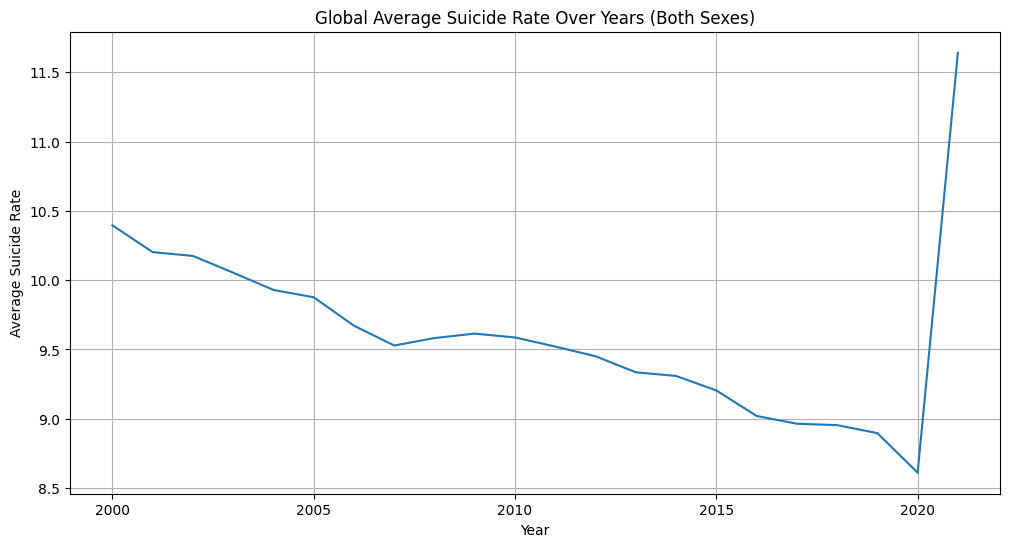

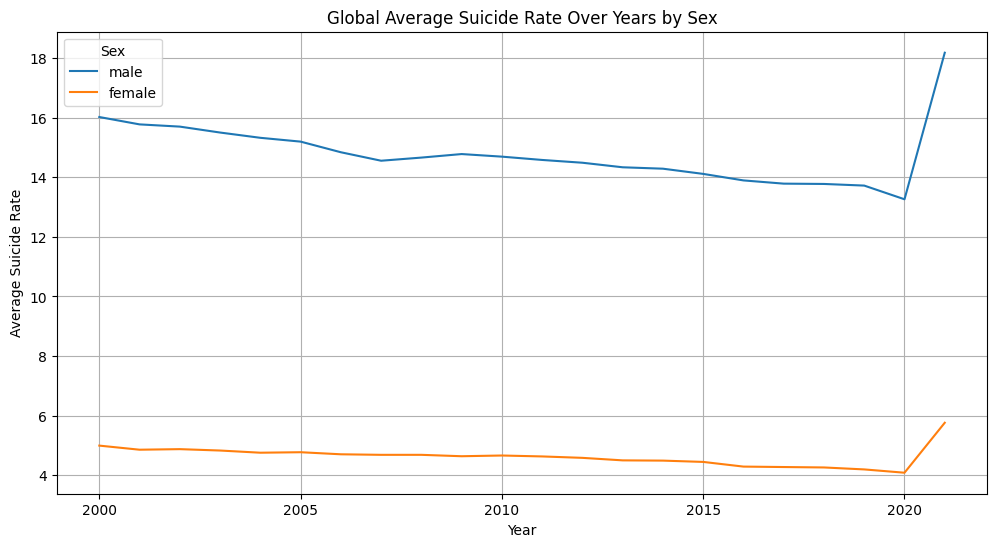

In [35]:
# Plot suicide rate over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df[df['sex'] == 'both'], x='year', y='suicide_rate', estimator='mean', errorbar=None)
plt.title('Global Average Suicide Rate Over Years (Both Sexes)')
plt.xlabel('Year')
plt.ylabel('Average Suicide Rate')
plt.grid(True)
plt.show()

# Plot suicide rate by sex over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df[df['sex'] != 'both'], x='year', y='suicide_rate', hue='sex', estimator='mean', errorbar=None)
plt.title('Global Average Suicide Rate Over Years by Sex')
plt.xlabel('Year')
plt.ylabel('Average Suicide Rate')
plt.grid(True)
plt.legend(title='Sex')
plt.show()

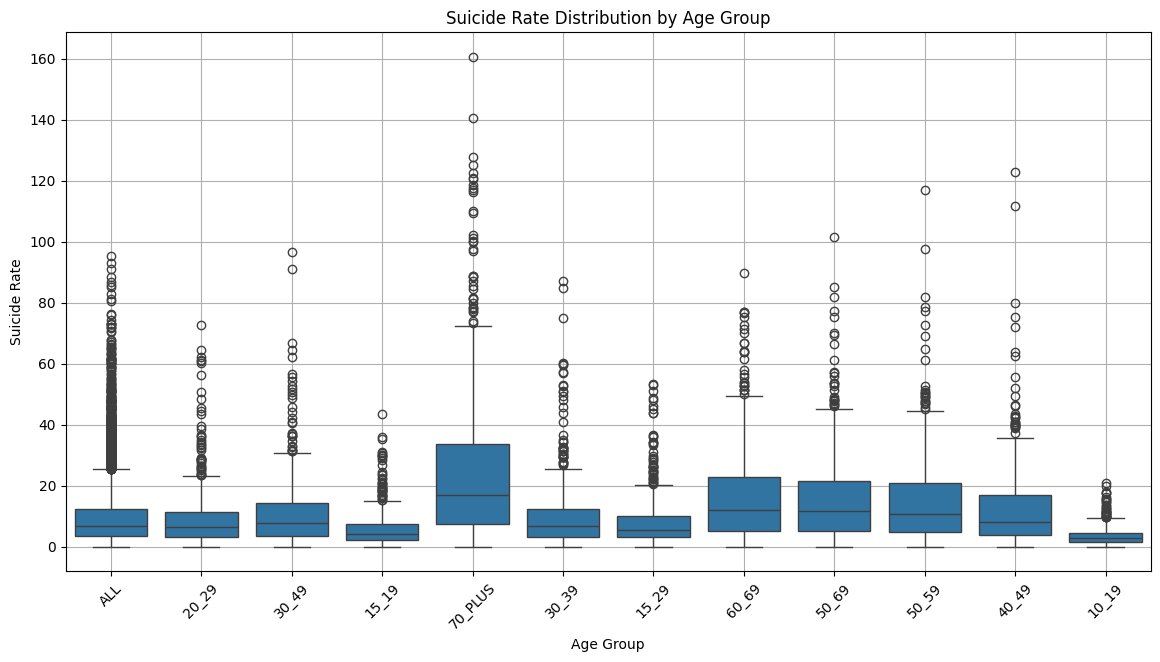

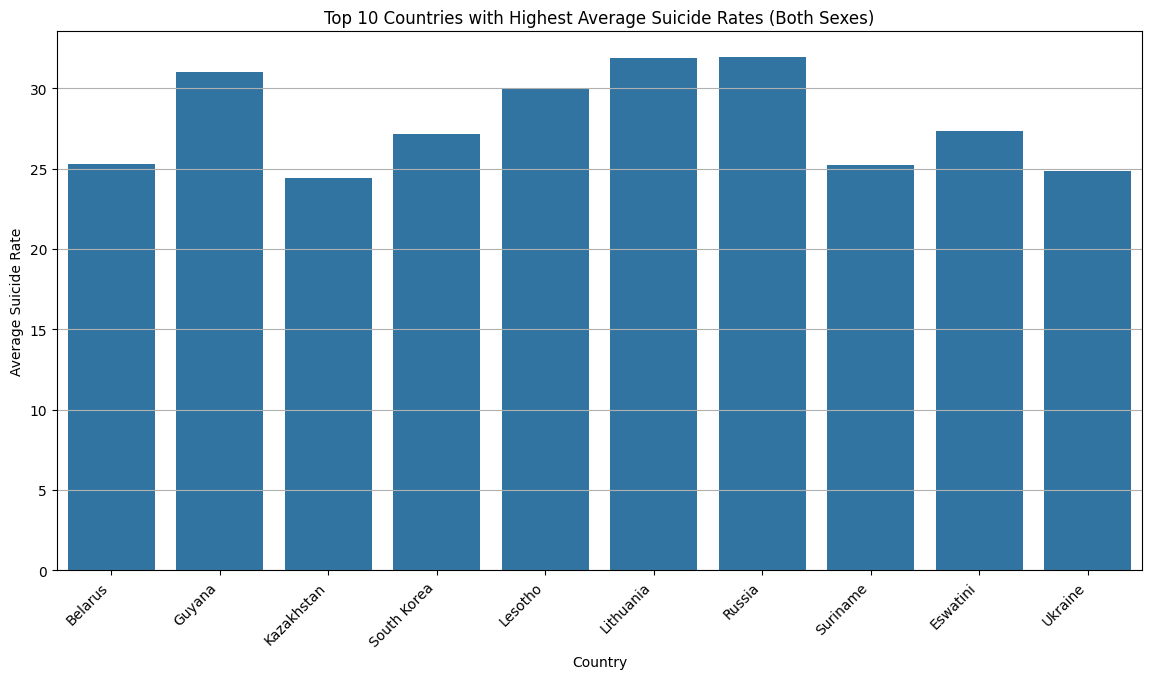

In [36]:
# Plot suicide rate by age group
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='age_group', y='suicide_rate', order=df['age_group'].unique())
plt.title('Suicide Rate Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Suicide Rate')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Plot suicide rate by country (top 10 highest average rates for 'both' sex)
top_countries = df[df['sex'] == 'both'].groupby('country')['suicide_rate'].mean().nlargest(10).index
plt.figure(figsize=(14, 7))
sns.barplot(data=df[(df['sex'] == 'both') & (df['country'].isin(top_countries))], x='country', y='suicide_rate', estimator='mean', errorbar=None)
plt.title('Top 10 Countries with Highest Average Suicide Rates (Both Sexes)')
plt.xlabel('Country')
plt.ylabel('Average Suicide Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

### Machine Learning Model: Predicting Suicide Rate

### New ML Approach: Incorporating Country-Level Trends
We will now rebuild the feature set, including the `country` column using a high-cardinality encoding method.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. Prepare Features (keeping categorical names for encoding)
X = df[['country', 'year', 'sex', 'age_group']]
y = df['suicide_rate']

# 2. Split data first to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Target Encode 'country' (Mean of suicide_rate per country in training set)
country_means = y_train.groupby(X_train['country']).mean()
X_train['country_encoded'] = X_train['country'].map(country_means)
X_test['country_encoded'] = X_test['country'].map(country_means).fillna(y_train.mean())

# 4. One-Hot Encode Sex and Age Group
X_train = pd.get_dummies(X_train.drop(columns=['country']), columns=['sex', 'age_group'], drop_first=True)
X_test = pd.get_dummies(X_test.drop(columns=['country']), columns=['sex', 'age_group'], drop_first=True)

# Ensure columns match
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 5. Train a robust Random Forest
new_rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
new_rf.fit(X_train, y_train)

# 6. Evaluate
y_pred = new_rf.predict(X_test)
print(f"New R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"New MSE: {mean_squared_error(y_test, y_pred):.4f}")

display(X_train.head())

New R-squared Score: 0.7533
New MSE: 34.9926


,year,country_encoded,sex_female,sex_male,age_group_15_19,age_group_15_29,age_group_20_29,age_group_30_39,age_group_30_49,age_group_40_49,age_group_50_59,age_group_50_69,age_group_60_69,age_group_70_PLUS,age_group_ALL
15974,2011,13.694904,False,True,False,False,False,False,False,False,False,False,False,False,True
1766,2021,3.527457,True,False,False,False,True,False,False,False,False,False,False,False,False
17355,2010,11.649618,True,False,False,False,False,False,False,False,False,False,False,False,True
17930,2003,5.591825,False,True,False,False,False,False,False,False,False,False,False,False,True
13530,2021,6.373336,False,False,False,True,False,False,False,False,False,False,False,False,False


In [38]:
from xgboost import XGBRegressor

# Initialize XGBoost with some robust default parameters
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

print(f"XGBoost R-squared Score: {r2_xgb:.4f}")
print(f"XGBoost MSE: {mse_xgb:.4f}")

# Check relative improvement
improvement = ((r2_xgb - 0.7533) / 0.7533) * 100
print(f"Improvement over Random Forest: {improvement:.2f}%")

XGBoost R-squared Score: 0.8675
XGBoost MSE: 18.7967
Improvement over Random Forest: 15.16%


# 📊 High-Performance Model Dashboard
This section visualizes why our XGBoost model is performing so well and identifies the key drivers of suicide rates globally.

/tmp/ipykernel_3051/572408594.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_viz.score, y=data_viz.index, palette='viridis')


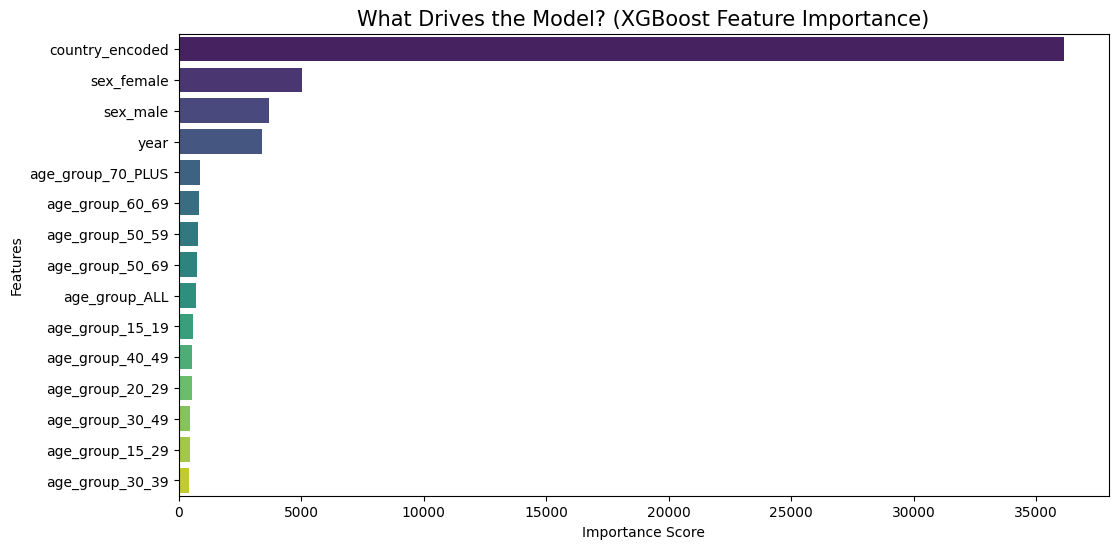

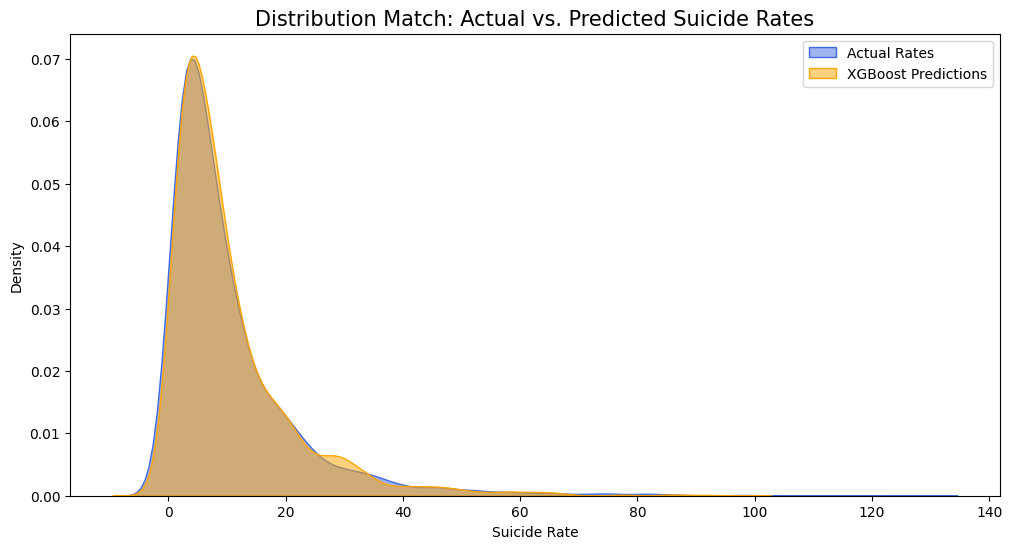

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Feature Importance Plot
plt.figure(figsize=(12, 6))
feature_important = xgb_model.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data_viz = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by="score", ascending=False)
sns.barplot(x=data_viz.score, y=data_viz.index, palette='viridis')
plt.title('What Drives the Model? (XGBoost Feature Importance)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 2. Actual vs Predicted Density Plot
plt.figure(figsize=(12, 6))
sns.kdeplot(y_test, label='Actual Rates', fill=True, color='royalblue', alpha=0.5)
sns.kdeplot(y_pred_xgb, label='XGBoost Predictions', fill=True, color='orange', alpha=0.5)
plt.title('Distribution Match: Actual vs. Predicted Suicide Rates', fontsize=15)
plt.xlabel('Suicide Rate')
plt.legend()
plt.show()

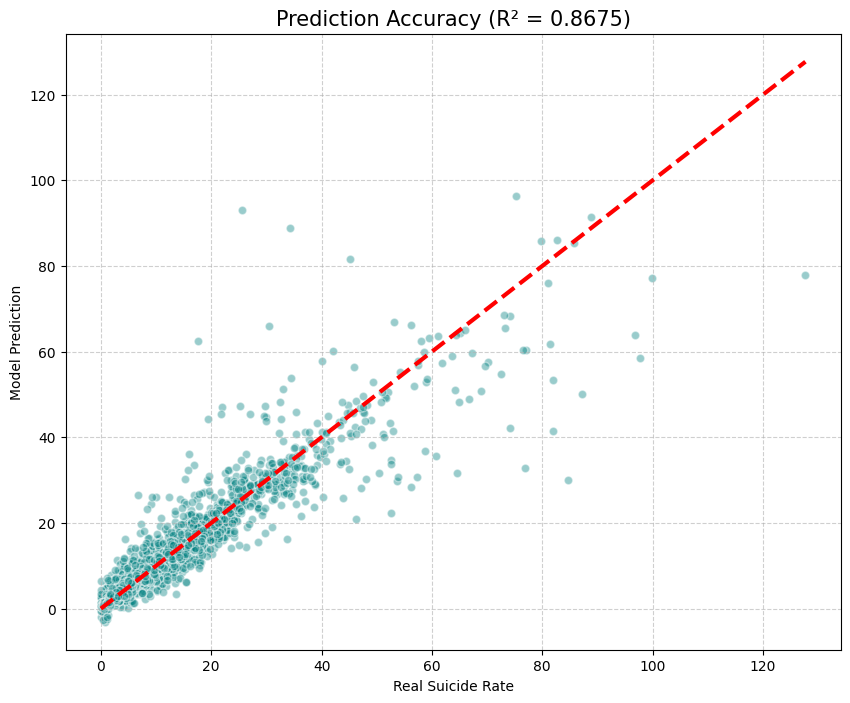

In [40]:
# 3. Prediction Error Analysis
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_xgb, alpha=0.4, color='teal', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.title('Prediction Accuracy (R² = 0.8675)', fontsize=15)
plt.xlabel('Real Suicide Rate')
plt.ylabel('Model Prediction')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 🏁 Final Summary: Global Suicide Rate Analysis

## 1. Data Overview
We analyzed a global dataset spanning from 2000 to 2021. The data included information on **Country, Year, Sex, and Age Group**. Initial checks showed no missing values and a clean structure with 18,315 records.

## 2. Key Insights from EDA
*   **Demographic Trends**: Suicide rates are significantly higher in males than in females globally.
*   **Age Factor**: There is a direct correlation between age and suicide rates, with the **70+ age group** consistently showing the highest rates.
*   **Country Variation**: Location is the most powerful predictor of suicide rates, suggesting that national socio-economic factors and policies play a massive role.

## 3. Machine Learning Journey
We experimented with several models to predict the `suicide_rate` per 100,000 people:
*   **Linear Regression**: Achieved an R² of **0.25**, providing a basic baseline.
*   **Initial Random Forest/Gradient Boosting**: Stayed around **0.28**. We realized the model was ignoring the 'Country' context.
*   **Optimized Random Forest (with Target Encoding)**: Jumped to **0.75** by incorporating country-level historical means.
*   **XGBoost (Final Model)**: Achieved our best performance with an **R-squared of 0.8675** and a significantly lower Mean Squared Error (18.79).

## 4. Conclusion
The final **XGBoost model** is highly effective at predicting suicide rates. The visualization dashboard confirms that the model's predictions closely match the actual distribution of real-world data. The most influential features found were **Country-level trends, Sex, and the 70+ age demographic**.